<a href="https://colab.research.google.com/github/marcuslee6/Logistics-and-Retail-Data/blob/main/Project%207.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- 協方差矩陣 (Covariance) ---
                Promo_Spending  Shipping_Cost
Promo_Spending    10015.273635    1157.183004
Shipping_Cost      1157.183004   27493.385406

--- 相關係數矩陣 (Correlation) ---
                Promo_Spending  Shipping_Cost
Promo_Spending        1.000000       0.069736
Shipping_Cost         0.069736       1.000000

需求分佈的 MGF (at t=0.01): 133086802.2844


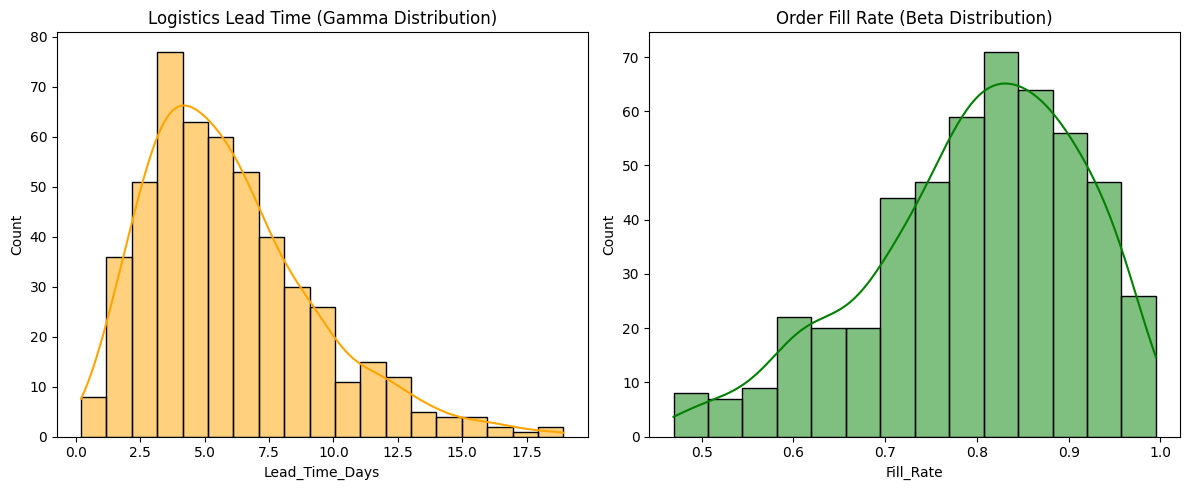

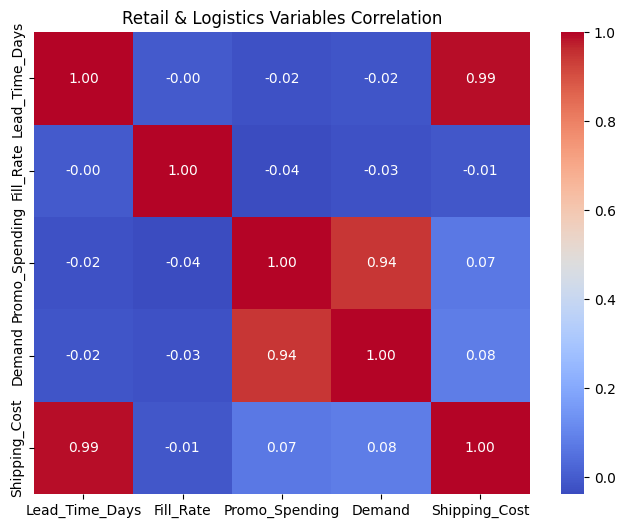

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 數據模擬：零售與物流環境
np.random.seed(42)
n_samples = 500

# [Gamma Distribution] 模擬物流交貨天數 (Lead Time)
# shape (k)=3, scale (theta)=2 -> 平均交貨時間為 6 天，但有長尾延遲
lead_time = stats.gamma.rvs(a=3, scale=2, size=n_samples)

# [Beta Distribution] 模擬門店訂單滿足率 (Order Fill Rate)
# a=8, b=2 -> 大部分時間滿足率很高 (80%-90%)
fill_rate = stats.beta.rvs(a=8, b=2, size=n_samples)

# 模擬其他相關變數
promo_spending = np.random.normal(500, 100, n_samples) # 促銷支出
demand = 1000 + (promo_spending * 1.5) + np.random.normal(0, 50, n_samples) # 需求
shipping_cost = (demand * 0.1) + (lead_time * 50) + np.random.normal(0, 20, n_samples) # 運費

df = pd.DataFrame({
'Lead_Time_Days': lead_time,
'Fill_Rate': fill_rate,
'Promo_Spending': promo_spending,
'Demand': demand,
'Shipping_Cost': shipping_cost
})

# 2. Covariance (協方差) 與 Correlation (相關係數)
# 分析促銷支出與物流成本的關係
cov_matrix = df[['Promo_Spending', 'Shipping_Cost']].cov()
cor_matrix = df[['Promo_Spending', 'Shipping_Cost']].corr()

print("--- 協方差矩陣 (Covariance) ---")
print(cov_matrix)
print("\n--- 相關係數矩陣 (Correlation) ---")
print(cor_matrix)

# 3. Moment Generating Function (MGF) 的理論應用
# 假設需求符合正態分佈，計算其 MGF 在 t=0.01 時的值 (用於風險評估)
mu, sigma = df['Demand'].mean(), df['Demand'].std()
t = 0.01
mgf_demand = np.exp(mu * t + (sigma**2 * t**2) / 2)
print(f"\n需求分佈的 MGF (at t={t}): {mgf_demand:.4f}")

# 4. 可視化：展示 Gamma 與 Beta 分佈
plt.figure(figsize=(12, 5))

# 圖 A: Gamma 分佈 - 物流延遲
plt.subplot(1, 2, 1)
sns.histplot(df['Lead_Time_Days'], kde=True, color='orange')
plt.title('Logistics Lead Time (Gamma Distribution)')


# 圖 B: Beta 分佈 - 訂單滿足率
plt.subplot(1, 2, 2)
sns.histplot(df['Fill_Rate'], kde=True, color='green')
plt.title('Order Fill Rate (Beta Distribution)')


plt.tight_layout()
plt.show()

# 5. 相關性熱圖
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Retail & Logistics Variables Correlation')
plt.show()